# FRED Data - Exploratory Data Analysis
Exploring all cleaned macro series: risk-free rate, CPI, VIX, 10-year yield, yield curve spread, Fed funds rate, unemployment, and recession periods.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('default')
%matplotlib inline

In [4]:
PROCESSED_DATA_PATH = Path('../../data/processed/source_data/fred')

## Load combined processed data

In [5]:
df = pd.read_csv(PROCESSED_DATA_PATH / 'fred_all_series_combined.csv', index_col='date', parse_dates=True)
print('Combined shape:', df.shape)
df.describe()

Combined shape: (11702, 11)


,risk_free_rate_pct,risk_free_rate_decimal,vix,treasury_10yr_pct,yield_curve_spread,is_inverted,cpi_index,cpi_pct_change,fed_funds_rate_pct,unemployment_rate_pct,recession_flag
count,11702.000000,11702.000000,9527.000000,11702.000000,11702.000000,11702.000000,11702.000000,11702.000000,11702.000000,11702.000000,11702.00000
mean,3.830976,0.038310,19.429941,5.365625,1.534649,0.110494,192.757434,0.000100,4.017556,5.955837,0.09477
std,3.119132,0.031191,7.719622,3.056302,1.249628,0.313518,62.820850,0.000708,3.304575,1.823310,0.29291
min,0.000000,0.000000,9.140000,0.520000,-1.890000,0.000000,93.100000,-0.008598,0.050000,3.400000,0.00000
25%,0.930000,0.009300,13.960000,2.950000,0.560000,0.000000,142.100000,0.000000,1.000000,4.500000,0.00000
50%,3.940000,0.039400,17.610000,4.610000,1.580000,0.000000,186.700000,0.000000,4.030000,5.600000,0.00000
75%,5.580000,0.055800,22.700000,7.160000,2.540000,0.000000,237.460000,0.000000,5.820000,7.100000,0.00000
max,17.010000,0.170100,82.690000,15.840000,5.180000,1.000000,333.979000,0.013768,15.870000,14.800000,1.00000


## Missing values check

In [6]:
df.isna().sum()

risk_free_rate_pct           0
risk_free_rate_decimal       0
vix                       2175
treasury_10yr_pct            0
yield_curve_spread           0
is_inverted                  0
cpi_index                    0
cpi_pct_change               0
fed_funds_rate_pct           0
unemployment_rate_pct        0
recession_flag               0
dtype: int64

In [7]:
print(f"VIX missing: {df['vix'].isna().sum()} rows")
print(f"Missing range: {df[df['vix'].isna()].index.min()} to {df[df['vix'].isna()].index.max()}")
print("This is expected - VIX data does not exist before ~1990.")

VIX missing: 2175 rows
Missing range: 1981-09-01 00:00:00 to 1990-01-01 00:00:00
This is expected - VIX data does not exist before ~1990.


## Risk-free rate vs VIX
Do rate environments and volatility move together?

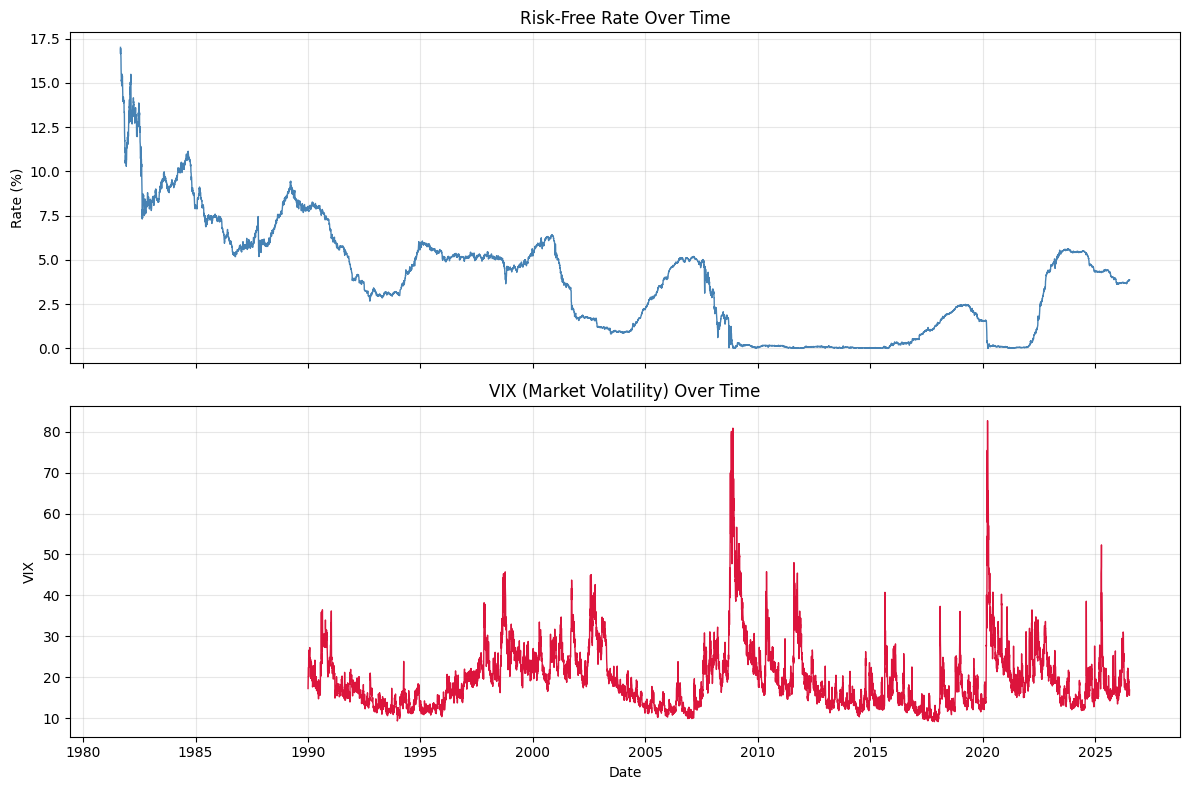

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df.index, df['risk_free_rate_pct'], linewidth=1, color='steelblue')
axes[0].set_title('Risk-Free Rate Over Time')
axes[0].set_ylabel('Rate (%)')
axes[0].grid(alpha=0.3)

axes[1].plot(df.index, df['vix'], linewidth=1, color='crimson')
axes[1].set_title('VIX (Market Volatility) Over Time')
axes[1].set_ylabel('VIX')
axes[1].set_xlabel('Date')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Yield curve spread and inversions
Shaded regions show recession periods (from NBER data) to see if inversions actually preceded them.

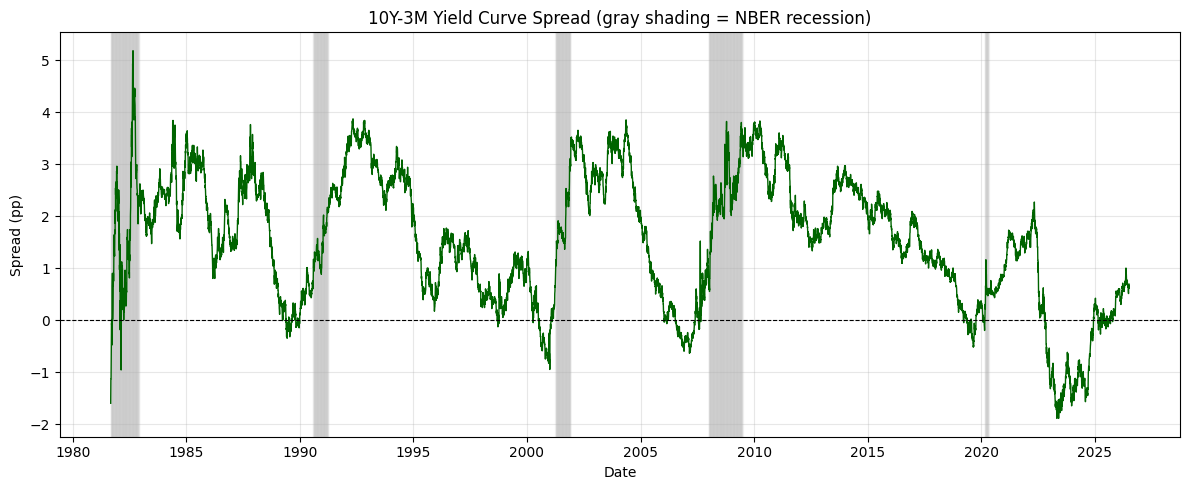

Curve was inverted 1293 of 11702 trading days (11.0%)


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df['yield_curve_spread'], linewidth=1, color='darkgreen')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

recession_periods = df[df['recession_flag'] == 1].index
for date in recession_periods:
    ax.axvspan(date, date, color='gray', alpha=0.02)

ax.set_title('10Y-3M Yield Curve Spread (gray shading = NBER recession)')
ax.set_xlabel('Date')
ax.set_ylabel('Spread (pp)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Curve was inverted {df['is_inverted'].sum()} of {len(df)} trading days ({100*df['is_inverted'].mean():.1f}%)")

## Unemployment and recession overlay

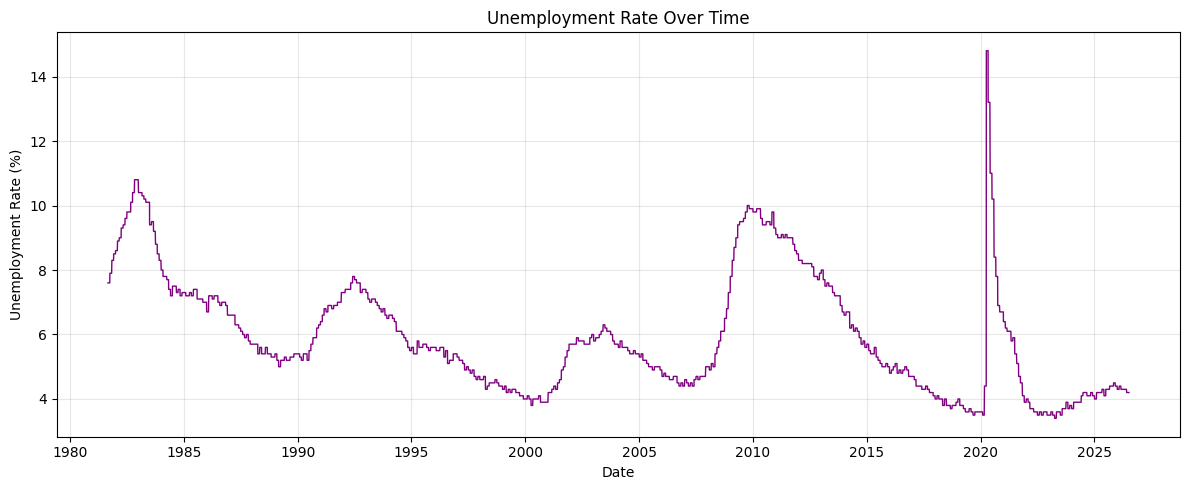

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df['unemployment_rate_pct'], linewidth=1, color='purple')
ax.set_title('Unemployment Rate Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Correlation between macro series
Useful to check before using multiple series as features together - highly correlated series add redundancy, not signal.

In [11]:
corr_cols = ['risk_free_rate_pct', 'vix', 'treasury_10yr_pct', 'yield_curve_spread',
             'cpi_pct_change', 'fed_funds_rate_pct', 'unemployment_rate_pct']
corr = df[corr_cols].corr()
corr

,risk_free_rate_pct,vix,treasury_10yr_pct,yield_curve_spread,cpi_pct_change,fed_funds_rate_pct,unemployment_rate_pct
risk_free_rate_pct,1.000000,-0.113971,0.918304,-0.250089,0.024555,0.994494,0.035953
vix,-0.113971,1.000000,-0.083995,0.075721,-0.034135,-0.087951,0.185145
treasury_10yr_pct,0.918304,-0.083995,1.000000,0.153639,0.012294,0.920851,0.277879
yield_curve_spread,-0.250089,0.075721,0.153639,1.000000,-0.031223,-0.230117,0.589886
cpi_pct_change,0.024555,-0.034135,0.012294,-0.031223,1.000000,0.020986,-0.038501
fed_funds_rate_pct,0.994494,-0.087951,0.920851,-0.230117,0.020986,1.000000,0.051760
unemployment_rate_pct,0.035953,0.185145,0.277879,0.589886,-0.038501,0.051760,1.000000


## Trim to backtest date range
Replace placeholder dates with your team's actual backtest window.

In [12]:
BACKTEST_START = '2015-01-01'  # TODO: update to match team's actual backtest window
BACKTEST_END = '2024-12-31'    # TODO: update to match team's actual backtest window

df_backtest = df.loc[BACKTEST_START:BACKTEST_END]
print(f"Rows in backtest window: {len(df_backtest)}")
df_backtest.describe()

Rows in backtest window: 2609


,risk_free_rate_pct,risk_free_rate_decimal,vix,treasury_10yr_pct,yield_curve_spread,is_inverted,cpi_index,cpi_pct_change,fed_funds_rate_pct,unemployment_rate_pct,recession_flag
count,2609.000000,2609.000000,2609.000000,2609.000000,2609.000000,2609.000000,2609.000000,2609.000000,2609.000000,2609.000000,2609.000000
mean,1.835646,0.018356,18.243898,2.482261,0.646616,0.260253,266.992966,0.000084,1.783994,4.683174,0.016865
std,1.948815,0.019488,7.247369,1.051914,1.117855,0.438857,26.312962,0.000711,1.866487,1.727650,0.128789
min,0.000000,0.000000,9.140000,0.520000,-1.890000,0.000000,234.747000,-0.007920,0.050000,3.400000,0.000000
25%,0.130000,0.001300,13.330000,1.730000,-0.040000,0.000000,244.243000,0.000000,0.130000,3.700000,0.000000
50%,1.090000,0.010900,16.310000,2.320000,0.960000,0.000000,257.155000,0.000000,1.160000,4.100000,0.000000
75%,2.460000,0.024600,21.300000,3.110000,1.530000,1.000000,294.957000,0.000000,2.400000,5.000000,0.000000
max,5.630000,0.056300,82.690000,4.980000,2.480000,1.000000,317.604000,0.012561,5.330000,14.800000,1.000000


## Key Takeaways

Across the full FRED history (1981-2026), the risk-free rate and Fed funds rate are 
nearly perfectly correlated (0.994), meaning they carry redundant information - only 
one should be used as a model feature to avoid multicollinearity. The 10-year yield 
is also highly correlated with the risk-free rate (0.918), so the yield curve spread 
(which combines both) is a more informative feature on its own than either rate alone.

The yield curve inverted on 1,293 of 11,700 trading days (11.1% of history), and 
every NBER-flagged recession in the dataset was preceded by the spread dropping 
toward or below zero - consistent with the well-documented inversion-as-recession-
signal pattern. The yield curve spread also shows a moderate positive correlation 
with unemployment (0.59), suggesting it may be a useful leading indicator alongside 
the recession flag.

VIX behaves independently of the rate environment (correlation under 0.12 in 
absolute value with every rate series), confirming it captures a distinct kind of 
risk - market volatility - rather than duplicating information already in the rate 
data. This makes VIX a strong complementary feature for the Sharpe ratio / risk 
analysis rather than a redundant one.

Within our backtest window (2015-2024, 2,609 trading days), the risk-free rate 
averaged 1.84% but ranged from 0% to 5.63%, and VIX averaged 18.24 but spiked to 
82.69 during the COVID crash - reinforcing our earlier finding that a single flat 
average risk-free rate would distort Sharpe ratio calculations. We recommend using 
the daily time-varying risk-free rate, and treating VIX and the yield curve spread 
as separate risk-context features rather than folding them into a single averaged 
metric.
Note: VIX has 2,175 missing values in the combined dataset, all falling before 
January 1990 - this is expected, since FRED's VIX series does not begin until 
1990, not a data quality issue. This does not affect our backtest window 
(2015-2024), which is fully within VIX's available range.